# Generalization_error_learning

In [1]:
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

#### Generating dataset (x_mu, y_mu), mu = 1,...,n


In [24]:
def gen_data(
    d: int, # hidden manifold dimension
    alpha: float, # n/p
    gamma: float, # d/p
    F: NDArray[np.floating], # size: dxp,
    theta_0: NDArray[np.floating], # size: dx1,
    sigma,
    f_0,
) -> tuple[NDArray[np.floating], NDArray[np.floating]]:

    p = math.floor(d / gamma) # number of features
    n = math.floor(alpha * p) # number of samples

    # drawing C (nxd) with i.i.d. N(0, 1) entries
    C = np.random.normal(0, 1, size=(n, d))

    y = f_0(C @ theta_0)
    X = sigma(C @ F)

    return X, y

In [ ]:
d=100
alpha = 0.5
gamma = 0.1
F = np.random.normal(0, 1, size=(d,  math.floor(d / gamma))) # Gaussian projections
theta_0=np.random.normal(0, 1, size=(d,))

X, y = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))


#### Generalization Errors

In [26]:
def ave_gen_error(
    d: int, # hidden manifold dimension
    alpha: float, # n/p
    gamma: float, # d/p
    lamb: float,
    sigma,
    f_0,
    f_hat,
    n_seeds: int,
    k=1,
    loss_fcn: str = "square"
) -> tuple[float, float]:

    p = math.floor(d / gamma) # number of features
    n = math.floor(alpha * p) # number of samples

    E_g = 0

    for i in range(1, n_seeds+1):
        # draw F, theta_0

        F = np.random.normal(0, 1, size=(d,  math.floor(d / gamma))) # Gaussian projections
        theta_0=np.random.normal(0, 1, size=(d,))

        X, y = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
 
        ## Square Loss
        if loss_fcn == "square":
            if n>p:
                w_hat = np.linalg.inv((X.T @ X + lamb * np.eye(p))) @ X.T @ y
            else:
                w_hat = X.T @ np.linalg.inv((X@ X.T + lamb * np.eye(n))) @ y
            
            loss = 1/2 * np.linalg.norm(y -  f_hat(X @ w_hat)) + lamb/2 * np.linalg.norm(w_hat)**2

        ## Logistic Loss
        elif loss_fcn == "logistic":
            clf = LogisticRegression(
                penalty="l2",
                C=1.0 / lamb if lamb > 0 else 1e12,
                fit_intercept=False,
                solver="lbfgs",
                max_iter=1000,
            )
            clf.fit(X, y)
            w_hat = clf.coef_.ravel()
            loss = np.log(1 + np.exp(-y * (X @ w_hat))).sum() + lamb/2 * np.linalg.norm(w_hat)**2
            
        #print(f"Training Loss: {loss}")
        
        X_new, y_new = gen_data(d=d, alpha=alpha, gamma=gamma, 
         F=F, theta_0=theta_0, sigma=lambda x: np.sign(x), f_0=lambda x: np.sign(x))
        #???

        
        E_g = E_g + (1/(4**k*n)) * np.linalg.norm(y_new -  f_hat(X_new @ w_hat))**2

    return E_g/n_seeds, loss

In [17]:
alphas = []

gen_errors_square = []
losses_square = []


for i in range(1,100):
    alpha = 1/i*20
    alphas.append(alpha)

    d=100
    gamma = alpha/3
    print(i)
    eps_g_square, loss_square = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=10, loss_fcn="square")
    gen_errors_square.append(eps_g_square)
    losses_square.append(loss_square)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [19]:
alphas = []

gen_errors_logistic = []
losses_logistic = []


for i in range(1,100):
    alpha = 1/i*20
    alphas.append(alpha)

    d=100
    gamma = alpha/3
    print(i)
    eps_g_logistic, loss_logistic = ave_gen_error(d=d, alpha=alpha, gamma=gamma, 
                      lamb=1e-4, sigma=lambda x: np.sign(x), 
                      f_0=lambda x: np.sign(x), f_hat=lambda x: np.sign(x), 
                      n_seeds=10, loss_fcn="logistic")
    gen_errors_logistic.append(eps_g_logistic)
    losses_logistic.append(loss_logistic)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


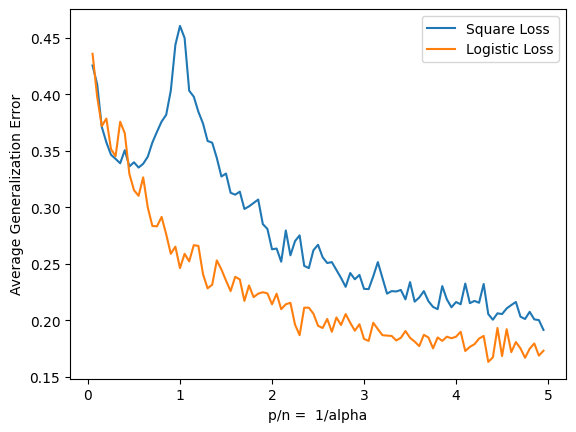

In [21]:

plt.plot([1/alpha for alpha in alphas],gen_errors_square)
plt.plot([1/alpha for alpha in alphas],gen_errors_logistic)
plt.xlabel('p/n =  1/alpha')
plt.ylabel('Average Generalization Error')
plt.legend(['Square Loss', 'Logistic Loss'])

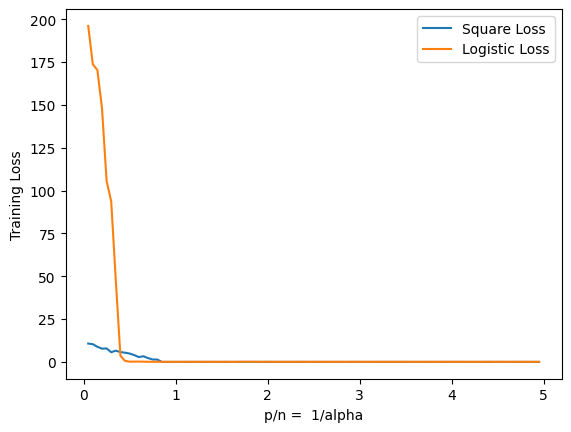

In [23]:
plt.plot([1/alpha for alpha in alphas], losses_square)
plt.plot([1/alpha for alpha in alphas], losses_logistic) 
plt.xlabel('p/n =  1/alpha')
plt.ylabel('Training Loss')
plt.legend(['Square Loss', 'Logistic Loss'])